In [ ]:
!pip install pandas pyarrow tqdm
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

In [ ]:
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random
import io
import gc
import pickle
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset,ConcatDataset, Subset
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, classification_report
)
import torch.nn.functional as F

from contextlib import suppress
from PIL import Image
import random
from torch.utils.data import Dataset

from itertools import product


In [ ]:
!nvidia-smi
print(torch.__version__)
print(torch.version.cuda)
print("cuda available?", torch.cuda.is_available())


Mon Apr 28 21:51:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
os.environ["HUGGINGFACE_HUB_TOKEN"] = 'hf_token'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# pick CUDA device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda:0


In [ ]:
splits = {'train': 'data/train-00000-of-00001.parquet',
          'validation': 'data/validation-00000-of-00001.parquet',
          'test': 'data/test-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/slegroux/tiny-imagenet-200-clean/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/slegroux/tiny-imagenet-200-clean/" + splits["test"])
df_val   = pd.read_parquet("hf://datasets/slegroux/tiny-imagenet-200-clean/" + splits["validation"])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Convert the 'image' column from dicts into raw bytes only
df_train['img_bytes'] = df_train['image'].apply(lambda x: x['bytes'])
df_val  ['img_bytes'] = df_val  ['image'].apply(lambda x: x['bytes'])
df_test  ['img_bytes'] = df_test  ['image'].apply(lambda x: x['bytes'])

print(df_train.columns)

print("Train examples:", len(df_train), "Val examples:", len(df_val))
print(df_train.columns.tolist())
print(df_train.head())


Index(['image', 'label', 'img_bytes'], dtype='object')
Train examples: 98179 Val examples: 4909
['image', 'label', 'img_bytes']
                                               image  label  \
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0   
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0   
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0   
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0   
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0   

                                           img_bytes  
0  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...  
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...  
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...  
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...  
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...  


In [ ]:
def stats_df(df):
    cnt = len(df)
    mem = df.memory_usage(deep=True).sum() / (1024**2)   # in MB
    return cnt, mem

stats = []
for name, df in [('train', df_train), ('validation', df_val), ('test', df_test)]:
    cnt, mem = stats_df(df)
    stats.append((name, cnt, f"{mem:.2f} MB"))

# total
total_cnt = sum(cnt for _, cnt, _ in stats)
total_mem = sum(float(mem.split()[0]) for _, _, mem in stats)
stats.append(('total', total_cnt, f"{total_mem:.2f} MB"))

# 4) (Optional) Get on-disk file sizes
for i, (name, _, _) in enumerate(stats[:-1]):
    path = splits[name]
    try:
        size_mb = os.path.getsize(path) / (1024**2)
    except FileNotFoundError:
        size_mb = None
    stats[i] = (name, stats[i][1], stats[i][2], f"{size_mb:.2f} MB" if size_mb is not None else "n/a")

# 5) Display as a table
import pandas as pd
cols = ['split', 'num_images', 'memory_usage', 'file_size_on_disk']
df_stats = pd.DataFrame(stats, columns=cols).set_index('split')
print(df_stats)

            num_images memory_usage file_size_on_disk
split                                                
train            98179    205.30 MB               n/a
validation        4909     10.25 MB               n/a
test              4923     10.27 MB               n/a
total           108011    225.82 MB              None


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),      # match pretrained’s expected size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225]),
])

In [ ]:
import io
from PIL import Image
from torch.utils.data import Dataset
from collections import defaultdict

class TinyImageNetDF(Dataset):
    def __init__(self, df, transform=None, pairs_per_epoch=100000):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.pairs_per_epoch = pairs_per_epoch
        self.label_to_indices = defaultdict(list)
        for i, lbl in enumerate(self.df["label"]):
            self.label_to_indices[lbl].append(i)
        self.labels = list(self.label_to_indices)


    def __len__(self):
        return self.pairs_per_epoch

    def _load_image(self, idx):
        b = self.df.loc[idx, "img_bytes"]
        img = Image.open(io.BytesIO(b)).convert("RGB")
        return self.transform(img) if self.transform else img

    def __getitem__(self, _):
        # 50% positive pairs
        if random.random() > 0.5:
            label = random.choice(self.labels)
            idx1, idx2 = random.sample(self.label_to_indices[label], 2)
            same_class = 1
        else:
            label1, label2 = random.sample(self.labels, 2)
            idx1 = random.choice(self.label_to_indices[label1])
            idx2 = random.choice(self.label_to_indices[label2])
            same_class = 0

        return (self._load_image(idx1), self._load_image(idx2)), torch.tensor(same_class, dtype=torch.float32)

In [ ]:
class MobilePairNetwork(nn.Module):  # Note: Inherits from nn.Module
    def __init__(self, backbone, in_feats, embedding_size=256):
        """
        Args:
            backbone: Pre-initialized MobileNetV2 backbone
            in_feats: Number of input features to projection head
            embedding_size: Size of final embedding (default: 256)
        """
        super(MobilePairNetwork, self).__init__()
        self.backbone = backbone
        # Remove the final classifier
        self.backbone.classifier = nn.Identity()

        # Add projection head for similarity learning
        self.projection = nn.Sequential(
            nn.Linear(in_feats, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_size)
        )

    def forward_one(self, x):
        """Process a single image"""
        features = self.backbone(x)
        return self.projection(features)

    def forward(self, x1, x2):
        """Process both images in the pair"""
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)
        return out1, out2


class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, out1, out2, y):

        out1 = F.normalize(out1, 2, 1)
        out2 = F.normalize(out2, 2, 1)
        d = (out1 - out2).pow(2).sum(1).sqrt()
        # now y=1 → similar
        loss = torch.mean(
            y      * d.pow(2) +                # pull same
            (1 - y) * F.relu(self.margin - d).pow(2)  # push diff
        )
        return loss

In [ ]:
train_ds = TinyImageNetDF(df_train, transform=transform,pairs_per_epoch=100000)
val_ds   = TinyImageNetDF(df_val,   transform=transform,pairs_per_epoch=10000)

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    prefetch_factor=4,
    num_workers=8,
    pin_memory=True,
    persistent_workers=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=256,
    prefetch_factor=4,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=False,
)



In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, epoch=None, total_epochs=None):
    model.train()
    running_loss = correct = total = 0
    desc = f"Epoch {epoch}/{total_epochs} ▶️ Train" if epoch else "Train"
    bar = tqdm(loader, desc=desc, leave=False, unit="batch")

    for (img1, img2), targets in bar:
        img1, img2 = img1.to(device), img2.to(device)
        targets     = targets.to(device)

        optimizer.zero_grad()
        out1, out2 = model(img1, img2)
        loss       = criterion(out1, out2, targets)
        loss.backward()
        optimizer.step()
        emb1      = F.normalize(out1, p=2, dim=1)
        emb2      = F.normalize(out2, p=2, dim=1)
        distances = F.pairwise_distance(emb1, emb2)

        preds  = (distances < 0.5).float()
        correct += (preds == targets).sum().item()
        total   += targets.size(0)

        running_loss += loss.item() * img1.size(0)
        bar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.3f}")

    return running_loss/total, correct/total


def validate(model, loader, criterion, threshold=0.5, epoch=None, total_epochs=None):
    model.eval()
    val_loss = val_correct = val_total = 0
    desc = f"Epoch {epoch}/{total_epochs} ✅ Val" if epoch else "Val"

    with torch.no_grad():
        for (img1, img2), targets in tqdm(loader, desc=desc, leave=False):
            img1, img2 = img1.to(device), img2.to(device)
            targets     = targets.to(device)

            out1, out2 = model(img1, img2)

            emb1      = F.normalize(out1, p=2, dim=1)
            emb2      = F.normalize(out2, p=2, dim=1)
            distances = F.pairwise_distance(emb1, emb2)

            loss = criterion(out1, out2, targets)

            preds      = (distances < threshold).float()

            val_correct += (preds == targets).sum().item()
            val_total   += targets.size(0)
            val_loss    += loss.item() * targets.size(0)

    return val_loss/val_total, val_correct/val_total

def make_model(num_classes=200, model_type='similarity'):
  backbone = models.mobilenet_v2(weights="IMAGENET1K_V1")
  in_feats = backbone.classifier[1].in_features

  model = MobilePairNetwork(backbone, in_feats)

  return model.to(device)


In [ ]:
# Speed-up tuning settings
tune_batch_size = 64
tune_epochs     = 3

tune_train_subset = torch.utils.data.Subset(train_ds, range(len(train_ds)//2))
tune_val_subset = torch.utils.data.Subset(val_ds, range(len(val_ds)//2))

tune_train_loader = DataLoader(tune_train_subset, batch_size=tune_batch_size, shuffle=True, num_workers=12)
tune_val_loader   = DataLoader(tune_val_subset, batch_size=tune_batch_size, shuffle=True, num_workers=12)

# Hyperparameter grid: learning rate and momentum
lrs = [0.01, 0.001]
moms = [0.8, 0.9]
fixed_wd = 1e-4

tune_results = {}

# Tuning loop with history capture
for lr, mom in product(lrs, moms):
    print(f"\n🔍 Tuning: lr={lr}, momentum={mom}")
    model = make_model(num_classes=200)
    criterion = ContrastiveLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=mom, weight_decay=fixed_wd)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, tune_epochs+1):
        train_loss, train_acc = train_one_epoch(
            model,
            tune_train_loader,
            criterion,
            optimizer,
            epoch,
            tune_epochs
        )
        val_loss, val_acc = validate(
            model,
            tune_val_loader,
            criterion,
            threshold=0.5,       # pick a threshold in [0,1]
            epoch=epoch,
            total_epochs=tune_epochs
        )
        print(
            f"Epoch {epoch:2d}  "
            f"Train ▶️ loss={train_loss:.4f}, acc={train_acc:.3f}  |  "
            f"Val ✅ loss={val_loss:.4f}, acc={val_acc:.3f}"
        )
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)


    tune_results[(lr, mom)] = history
    del model, optimizer, criterion
    torch.cuda.empty_cache(); gc.collect()


In [ ]:
# Select best hyperparams
best_lr, best_mom = max(tune_results, key=lambda k: tune_results[k]['val_acc'][-1])
print(f"🏆 Best: lr={best_lr}, momentum={best_mom}")

In [ ]:
with open('tune_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'tune_results': tune_results,
        'history': history,
        'lrs': lrs,
        'moms': moms,
        'tune_epochs': tune_epochs,
        'best_params': (best_lr, best_mom)
    }, f)
print("🔖 Saved tuning artifacts → tune_artifacts.pkl")

In [ ]:
with open('tune_artifacts (2).pkl', 'rb') as f:
    data = pickle.load(f)
tune_results = data['tune_results']
lrs          = data['lrs']
moms         = data['moms']
tune_epochs  = data['tune_epochs']
best_lr, best_mom = data['best_params']

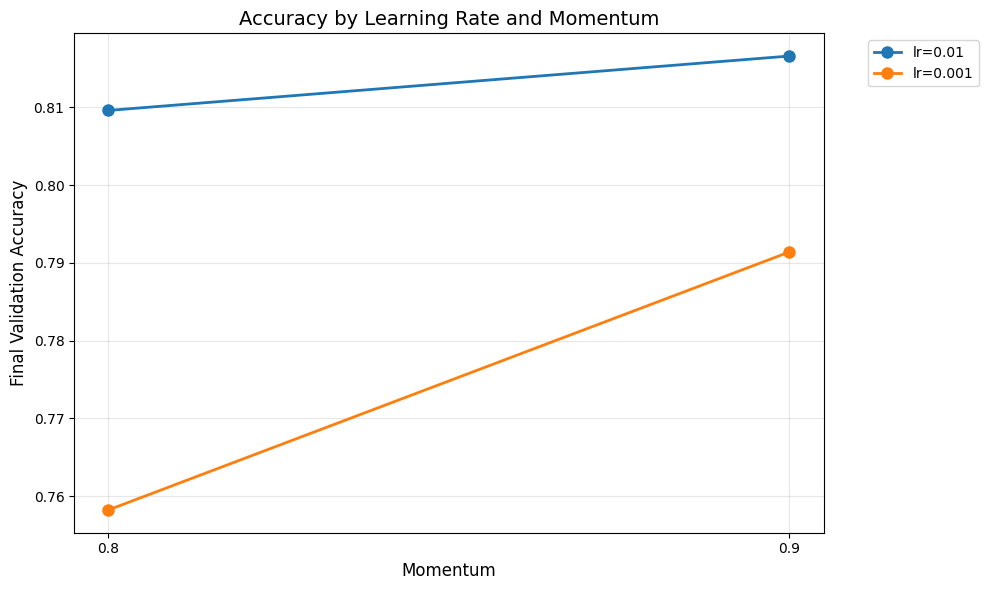

In [ ]:
plt.figure(figsize=(10, 6))

for lr in lrs:
    accuracies = [tune_results[(lr, mom)]['val_acc'][-1] for mom in moms]
    plt.plot(moms, accuracies, '-o', label=f'lr={lr}', linewidth=2, markersize=8)

plt.xlabel('Momentum', fontsize=12)
plt.ylabel('Final Validation Accuracy', fontsize=12)
plt.title('Accuracy by Learning Rate and Momentum', fontsize=14)
plt.xticks(moms)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

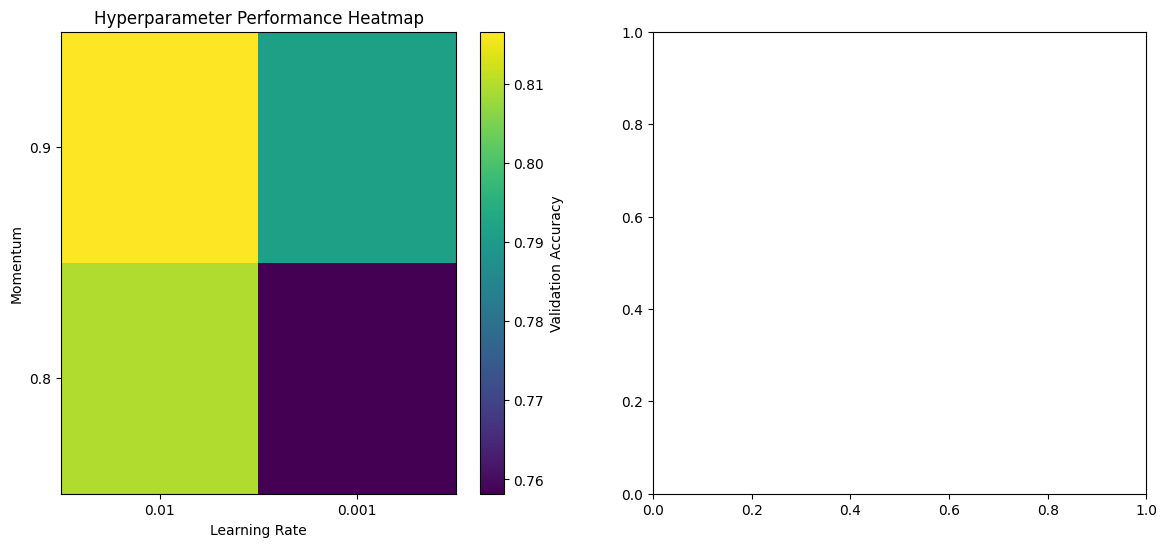

<Figure size 1000x600 with 0 Axes>

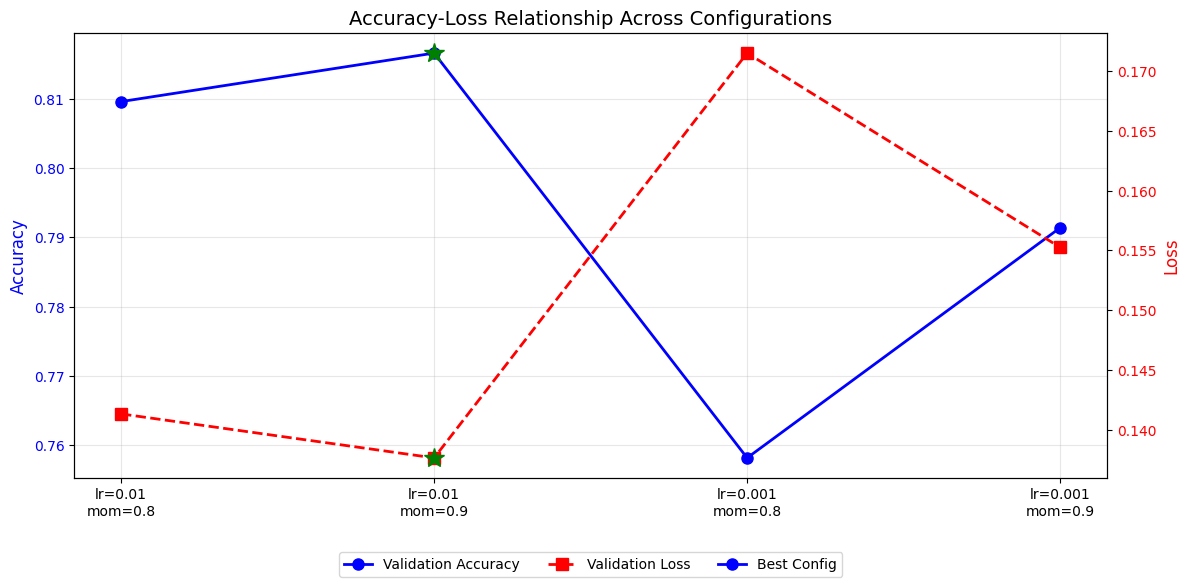

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
acc_matrix = np.zeros((len(moms), len(lrs)))
for i, mom in enumerate(moms):
    for j, lr in enumerate(lrs):
        acc_matrix[i, j] = tune_results[(lr, mom)]['val_acc'][-1]

im = ax1.imshow(acc_matrix, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax1, label='Validation Accuracy')
ax1.set_xticks(range(len(lrs)), lrs)
ax1.set_yticks(range(len(moms)), moms)
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Momentum")
ax1.set_title("Hyperparameter Performance Heatmap")

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Extract final metrics for all configurations
configs = []
val_accs = []
val_losses = []
for (lr, mom), hist in tune_results.items():
    configs.append(f"lr={lr}\nmom={mom}")
    val_accs.append(hist['val_acc'][-1])
    val_losses.append(hist['val_loss'][-1])

# Create twin axes
fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()

# Plot accuracy (left axis)
acc_line = ax1.plot(configs, val_accs, 'b-o',
                   label='Validation Accuracy',
                   linewidth=2, markersize=8)
ax1.set_ylabel('Accuracy', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# Plot loss (right axis)
loss_line = ax2.plot(configs, val_losses, 'r--s',
                    label='Validation Loss',
                    linewidth=2, markersize=8)
ax2.set_ylabel('Loss', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

# Highlight best configuration
best_idx = np.argmax(val_accs)
ax1.plot(configs[best_idx], val_accs[best_idx],
        'g*', markersize=15, label='Best Config')
ax2.plot(configs[best_idx], val_losses[best_idx],
        'g*', markersize=15)

# Formatting
plt.title('Accuracy-Loss Relationship Across Configurations', fontsize=14)
plt.xticks(rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

# Combine legends
lines = acc_line + loss_line
labels = [l.get_label() for l in lines] + ['Best Config']
ax1.legend(lines + [acc_line[0]], labels,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.15),
          ncol=3)

plt.tight_layout()
plt.show()

In [ ]:
# Final training on full train+val
combined = ConcatDataset([train_ds, val_ds])
full_train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=12)
full_val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=12)

final_model = make_model()
optimizer = optim.SGD(final_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
criterion = ContrastiveLoss()
num_epochs = 10
final_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_lr,best_mom=0.01,0.9
for epoch in range(1, num_epochs+1):
    train_loss, train_acc = train_one_epoch(
        final_model,
        full_train_loader,
        criterion,
        optimizer,
        epoch,
        num_epochs
    )
    val_loss, val_acc = validate(
        final_model,
        full_val_loader,
        criterion,
        threshold=0.5,
        epoch=epoch,
        total_epochs=num_epochs
    )
    print(
        f"Epoch {epoch:2d}  "
        f"Train ▶️ loss={train_loss:.4f}, acc={train_acc:.3f}  |  "
        f"Val ✅ loss={val_loss:.4f}, acc={val_acc:.3f}"
    )
    final_history['train_loss'].append(train_loss)
    final_history['train_acc'].append(train_acc)
    final_history['val_loss'].append(val_loss)
    final_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:2d}  Train ▶️ loss={final_history['train_loss'][-1]:.4f}, acc={final_history['train_acc'][-1]:.3f}  |  "
          f"Val ✅ loss={final_history['val_loss'][-1]:.4f}, acc={final_history['val_acc'][-1]:.3f}")



Epoch 1/10 ▶️ Train:   0%|          | 0/1563 [00:00<?, ?batch/s]

Epoch 1/10 ✅ Val:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch  1  Train ▶️ loss=0.1589, acc=0.779  |  Val ✅ loss=0.1432, acc=0.796
Epoch  1  Train ▶️ loss=0.1589, acc=0.779  |  Val ✅ loss=0.1432, acc=0.796


Epoch 2/10 ▶️ Train:   0%|          | 0/1563 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af8f437c540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af8f437c540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 16

...

Epoch  9  Train ▶️ loss=0.1026, acc=0.869  |  Val ✅ loss=0.1232, acc=0.830
Epoch  9  Train ▶️ loss=0.1026, acc=0.869  |  Val ✅ loss=0.1232, acc=0.830


Epoch 10/10 ▶️ Train:   0%|          | 0/1563 [00:00<?, ?batch/s]

Epoch 10/10 ✅ Val:   0%|          | 0/157 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af8f437c540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
         Exception ignored in:   ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7af8f437c540>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
^    ^self._shutdown_workers()^
^^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^ ^ ^ ^^ ^^^^

Epoch 10  Train ▶️ loss=0.1012, acc=0.871  |  Val ✅ loss=0.1242, acc=0.825
Epoch 10  Train ▶️ loss=0.1012, acc=0.871  |  Val ✅ loss=0.1242, acc=0.825


In [ ]:
import torch
import pickle

torch.save(final_model.state_dict(), 'mobilenet_final.pth')
with open('final_history.pkl', 'wb') as f:
    pickle.dump(final_history, f)
print("🔖 Saved final model → mobilenet_final.pth")
print("🔖 Saved final training history → final_history.pkl")

🔖 Saved final model → mobilenet_final.pth
🔖 Saved final training history → final_history.pkl


In [ ]:
torch.save(final_model, "mobilenet_tinyimagenet_full.pth")

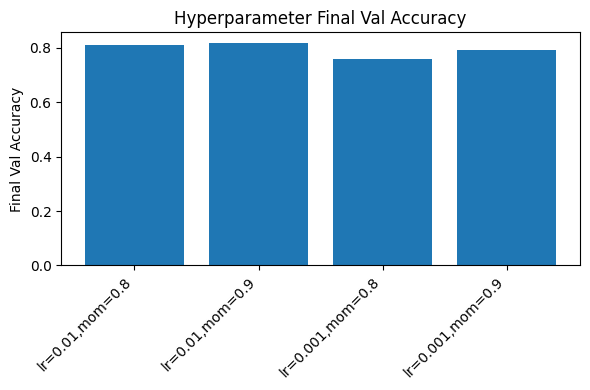

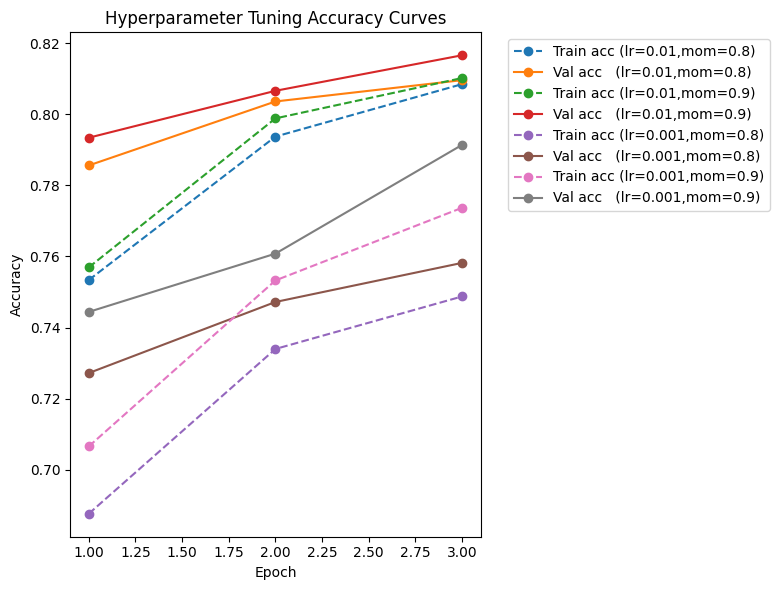

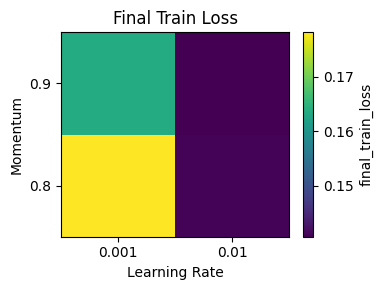

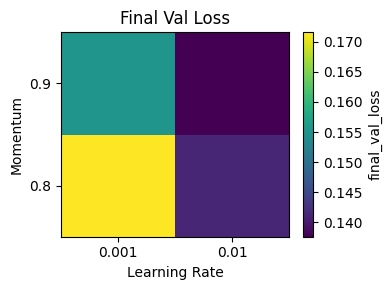

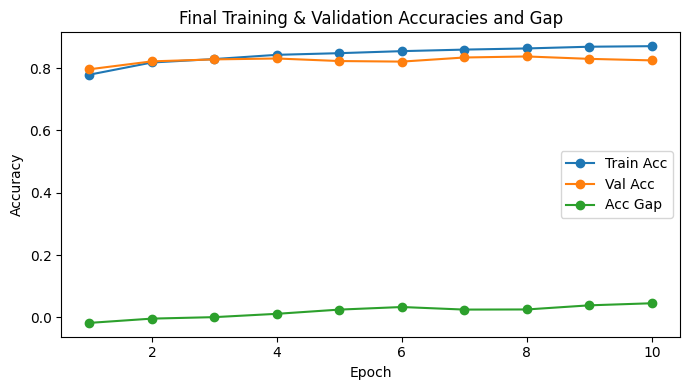

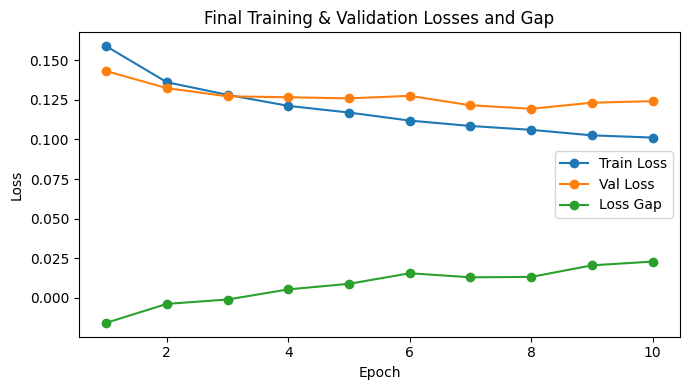

AttributeError: 'list' object has no attribute 'to'

In [ ]:
rows = []
for (lr, mom), hist in tune_results.items():
    rows.append({
        'lr': lr,
        'momentum': mom,
        'final_train_acc': hist['train_acc'][-1],
        'final_val_acc':   hist['val_acc'][-1],
        'final_train_loss': hist['train_loss'][-1],
        'final_val_loss':   hist['val_loss'][-1]
    })
df_tune = pd.DataFrame(rows)

# Bar chart of final validation accuracy for each (lr, momentum) pair
plt.figure(figsize=(6,4))
labels = [f"lr={r.lr},mom={r.momentum}" for _, r in df_tune.iterrows()]
plt.bar(labels, df_tune['final_val_acc'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Final Val Accuracy")
plt.title("Hyperparameter Final Val Accuracy")
plt.tight_layout()
plt.show()

# Line plots of train vs val accuracy across epochs for each config
plt.figure(figsize=(8,6))
for (lr, mom), hist in tune_results.items():
    epochs = list(range(1, tune_epochs+1))
    plt.plot(epochs, hist['train_acc'], '--', marker='o', label=f"Train acc (lr={lr},mom={mom})")
    plt.plot(epochs, hist['val_acc'],  '-',  marker='o', label=f"Val acc   (lr={lr},mom={mom})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Hyperparameter Tuning Accuracy Curves")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Heatmaps: final train & val loss
for metric in ['final_train_loss', 'final_val_loss']:
    mat = df_tune.pivot(index='momentum', columns='lr', values=metric)
    plt.figure(figsize=(4,3))
    plt.imshow(mat, origin='lower', aspect='auto')
    plt.title(metric.replace('_',' ').title())
    plt.xlabel("Learning Rate")
    plt.ylabel("Momentum")
    plt.colorbar(label=metric)
    plt.xticks(range(len(mat.columns)), mat.columns)
    plt.yticks(range(len(mat.index)), mat.index)
    plt.tight_layout()
    plt.show()

# (a) Train, Val, and Gap in accuracy
epochs = list(range(1, num_epochs+1))
train_acc = np.array(final_history['train_acc'])
val_acc   = np.array(final_history['val_acc'])
gap       = train_acc - val_acc

plt.figure(figsize=(7,4))
plt.plot(epochs, train_acc, '-o', label='Train Acc')
plt.plot(epochs, val_acc,   '-o', label='Val Acc')
plt.plot(epochs, gap,       '-o', label='Acc Gap')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Training & Validation Accuracies and Gap")
plt.legend()
plt.tight_layout()
plt.show()

# (b) Train vs Val Loss & Gap
train_loss = np.array(final_history['train_loss'])
val_loss   = np.array(final_history['val_loss'])
loss_gap   = val_loss - train_loss

plt.figure(figsize=(7,4))
plt.plot(epochs, train_loss, '-o', label='Train Loss')
plt.plot(epochs, val_loss,   '-o', label='Val Loss')
plt.plot(epochs, loss_gap,   '-o', label='Loss Gap')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Training & Validation Losses and Gap")
plt.legend()
plt.tight_layout()
plt.show()

from collections import Counter
# Gather predictions
all_preds, all_labels = [], []
final_model.eval()
with torch.no_grad():
    for imgs, labels in full_val_loader:
        imgs = imgs.to(device)
        preds = final_model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

support = Counter(all_labels)
correct_counts = Counter([true for true, pred in zip(all_labels, all_preds) if true == pred])
per_class_acc = {cls: correct_counts[cls]/support[cls] for cls in support}

top10 = [cls for cls, _ in support.most_common(10)]
accs10 = [per_class_acc[cls] for cls in top10]

plt.figure(figsize=(6,4))
plt.bar(range(10), accs10)
plt.xticks(range(10), top10, rotation=45, ha='right')
plt.xlabel("Class Label")
plt.ylabel("Accuracy")
plt.title("Top-10 Classes by Support: Validation Accuracy")
plt.tight_layout()
plt.show()

In [ ]:
import torch

sd = torch.load("mobilenet_final_pair.pth", map_location="cpu")
print("✅ Loaded state dict. Keys:")
print(sorted(sd.keys())[:10], "...", len(sd))

✅ Loaded state dict. Keys:
['backbone.features.0.0.weight', 'backbone.features.0.1.bias', 'backbone.features.0.1.num_batches_tracked', 'backbone.features.0.1.running_mean', 'backbone.features.0.1.running_var', 'backbone.features.0.1.weight', 'backbone.features.1.conv.0.0.weight', 'backbone.features.1.conv.0.1.bias', 'backbone.features.1.conv.0.1.num_batches_tracked', 'backbone.features.1.conv.0.1.running_mean'] ... 316


In [ ]:
final_model = make_model(num_classes=200)

# Load the saved weights onto CPU
sd = torch.load("mobilenet_final_pair.pth", map_location="cpu")

# Now *strictly* load
final_model.load_state_dict(sd)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model = final_model.to(device).eval()
print("✅ Model loaded and on", device)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 229MB/s]


✅ Model loaded and on cuda


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from PIL import Image
import io

def compute_test_embeddings(model, dataset, transform, device):
    """
    Precompute embeddings for all test images.
    """
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Computing Test Embeddings"):
            # Access DataFrame row correctly
            row = dataset.iloc[idx]
            img = Image.open(io.BytesIO(row['img_bytes'])).convert('RGB')
            label = row['label']

            img_tensor = transform(img).unsqueeze(0).to(device)

            with torch.cuda.amp.autocast():
                output = model.forward_one(img_tensor)
            all_embeddings.append(output.squeeze(0).cpu().numpy())
            all_labels.append(label)

    embeddings = np.stack(all_embeddings)
    labels = np.array(all_labels)

    return embeddings, labels

embeddings, labels = compute_test_embeddings(final_model, df_test, transform, device)

Computing Test Embeddings:   0%|          | 0/4923 [00:00<?, ?it/s]<ipython-input-16-22c08e5ad29a>:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Computing Test Embeddings: 100%|██████████| 4923/4923 [00:49<00:00, 98.96it/s]


In [ ]:
N = len(labels)

if num_pairs is None:
    # full nC2
    total_pairs = N*(N-1)//2
    print(f"→ Generating ALL {total_pairs:,} pairs …")
    sampled_pairs = [(i,j) for i in range(N) for j in range(i+1, N)]
else:
    print(f"→ Sampling {num_pairs:,} random unique pairs …")
    sampled_pairs = set()
    pbar = tqdm(total=num_pairs, desc="Sampling random pairs")
    while len(sampled_pairs) < num_pairs:
        i, j = random.sample(range(N), 2)
        if i>j: i,j = j,i
        if (i,j) not in sampled_pairs:
            sampled_pairs.add((i,j))
            pbar.update()
    pbar.close()
    sampled_pairs = list(sampled_pairs)

print(f"✅ Built {len(sampled_pairs):,} pairs.")

In [ ]:
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

def evaluate_similarity(
    embeddings, labels, pairs,
    threshold: float = 0.75,
    log_every: int = 100_000
):
    """Run through `pairs`, compute cosine sim, live‐update metrics."""
    # assume embeddings are L2-normalized rows already
    preds, truths, scores = [], [], []
    running_correct = 0

    bar = tqdm(enumerate(pairs), total=len(pairs),
               desc="Evaluating Pairs", unit="pair")
    for k, (i, j) in bar:
        # fast dot of two normalized vectors = cosine_sim
        sim = float(np.dot(embeddings[i], embeddings[j]))

        pred = int(sim > threshold)
        true = int(labels[i] == labels[j])

        preds.append(pred)
        truths.append(true)
        scores.append(sim)

        running_correct += (pred == true)
        if (k + 1) % log_every == 0:
            bar.set_postfix(acc=f"{running_correct/(k+1):.4f}")

    # final metrics
    acc  = accuracy_score(truths, preds)
    prec = precision_score(truths, preds, zero_division=0)
    rec  = recall_score(truths, preds, zero_division=0)
    f1   = f1_score(truths, preds, zero_division=0)

    print(f"\n✅ Done.  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return preds, truths, scores

# ─ call it ─
all_preds, all_truths, all_scores = evaluate_similarity(
    embeddings, labels, sampled_pairs,
    threshold=0.75, log_every=100_000
)

▶️ Final overall accuracy: 0.8325


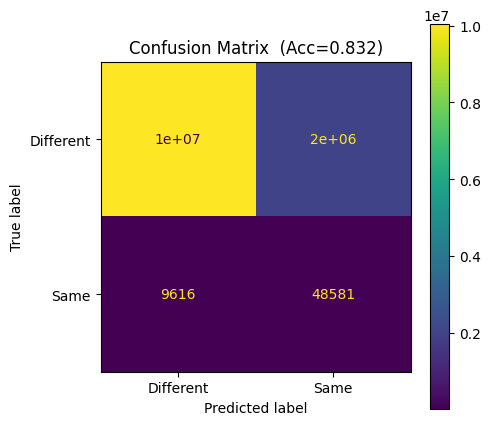

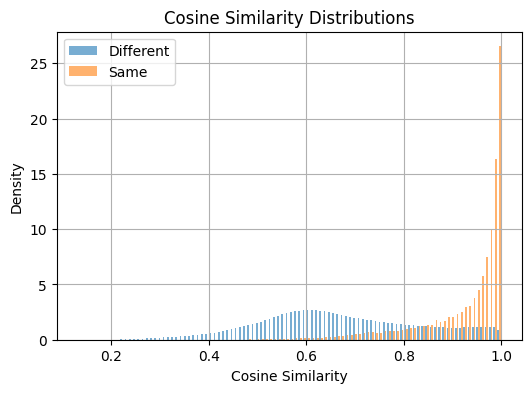

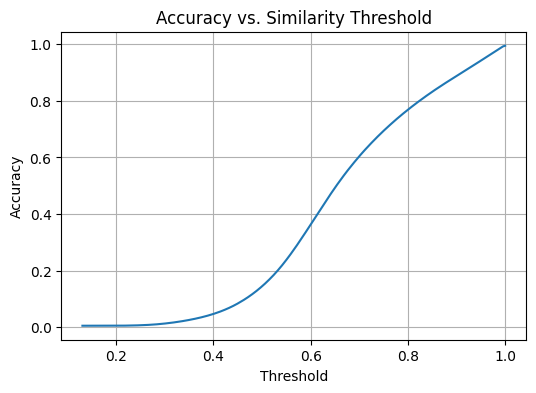

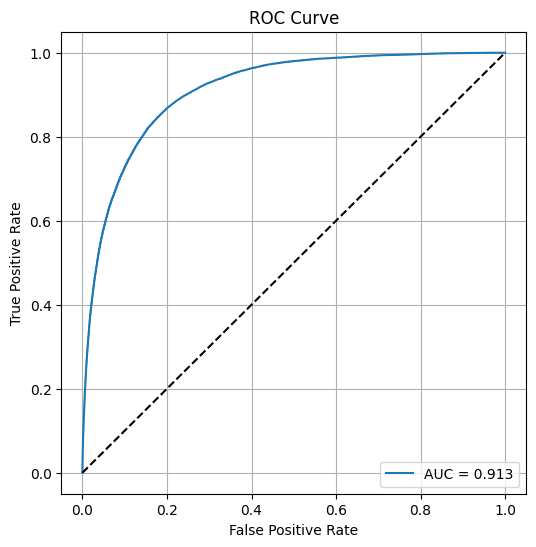

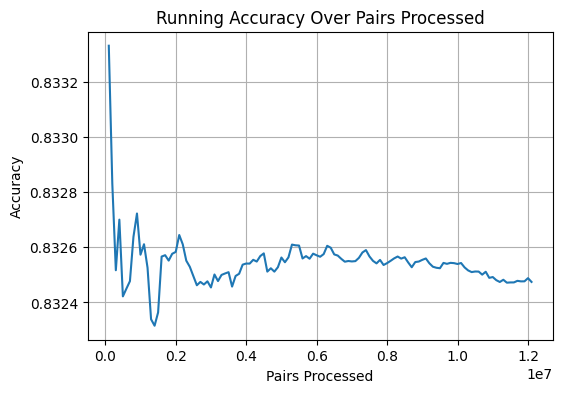

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay
)

scores = np.array(all_scores)
truths = np.array(all_truths)
preds  = np.array(all_preds)

print(f"▶️ Final overall accuracy: {acc:.4f}")

cm = confusion_matrix(truths, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Different","Same"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax)
ax.set_title(f"Confusion Matrix  (Acc={acc:.3f})")
plt.show()

plt.figure(figsize=(6,4))
plt.hist([scores[truths==0], scores[truths==1]],
         bins=100, density=True, alpha=0.6,
         label=["Different", "Same"])
plt.title("Cosine Similarity Distributions")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

thresholds = np.linspace(scores.min(), scores.max(), 200)
accuracies = [ accuracy_score(truths, (scores > t).astype(int)) for t in thresholds ]

plt.figure(figsize=(6,4))
plt.plot(thresholds, accuracies)
plt.title("Accuracy vs. Similarity Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

fpr, tpr, _ = roc_curve(truths, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

interval = 100_000
steps = list(range(interval, len(preds), interval))
running_acc = [
    np.mean(preds[:i] == truths[:i])
    for i in steps
]

plt.figure(figsize=(6,4))
plt.plot(steps, running_acc)
plt.title("Running Accuracy Over Pairs Processed")
plt.xlabel("Pairs Processed")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


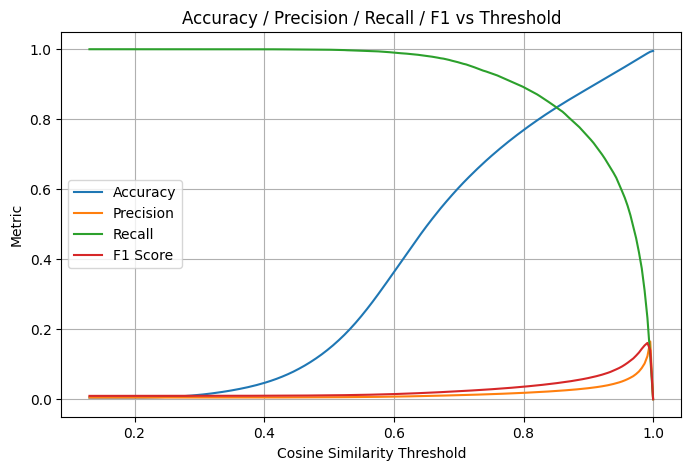

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# assume truths and scores are in your workspace
truths = np.array(all_truths)
scores = np.array(all_scores)

# build a list of thresholds
thresholds = np.linspace(scores.min(), scores.max(), 200)

accs = []
precisions = []
recalls = []
f1s = []

for t in thresholds:
    preds_t = (scores > t).astype(int)
    accs.append(accuracy_score(truths, preds_t))
    # handle edge-case of no positives predicted
    precisions.append(precision_score(truths, preds_t, zero_division=0))
    recalls.append(recall_score(truths, preds_t, zero_division=0))
    f1s.append(f1_score(truths, preds_t, zero_division=0))

plt.figure(figsize=(8,5))
plt.plot(thresholds, accs,       label="Accuracy")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls,    label="Recall")
plt.plot(thresholds, f1s,        label="F1 Score")
plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Metric")
plt.title("Accuracy / Precision / Recall / F1 vs Threshold")
plt.legend(loc="best")
plt.grid(True)
plt.show()